# AI와 함께 타이타닉 데이터 분석 한 사이클 완주하기 (STEP 00–12)

Titanic 데이터를 이용해 데이터 로딩부터 EDA, 통계 검정, 전처리, 그리고 첫 모델 학습(Logistic
Regression)까지 STEP 00–12를 진행합니다. STEP 13 이후 평가·추가 모델·저장·서비스는 별도로 이어집니다.

**DataFrame 역할 구분**

- `df` : 원본 기준 데이터
- `df_work` : STEP 05–10 탐색·EDA용 작업본
- `df_encoded` : STEP 07 인코딩 원리 학습용 복사본
- `feature_demo` : STEP 10 파생 Feature 실험용 복사본
- `model_source` : STEP 11부터 모델링을 위해 원본 `df`에서 다시 만든 데이터

**가장 중요한 원칙**

1. 앞에서 인코딩과 결측치 처리를 연습했더라도 모델링에서는 원본 `df`에서 다시 시작한다.
2. Train/Test를 먼저 나눈 뒤, Train에서만 결측치 처리·인코딩·스케일링 기준을 학습한다.

## Part 1. 데이터 이해·전처리·EDA·Feature 설계 (STEP 00–10)

## STEP 00. 전체 분석 지도 먼저 보기

환경 확인 → 데이터 로딩 → 데이터 품질 확인 → Target 정의 → 결측치 처리 원리 → 컬럼 검토
→ 인코딩 원리 → 시각화 → 기초 통계와 통계 검정 → Feature 설계 → Train/Test 분리
→ 결측치 처리 → 인코딩 → 정규화/표준화 → 모델 학습 → 평가와 오류 분석 → 추가 모델
→ 최종 모델 선택 → 저장과 신규 예측 → Streamlit 서비스

Titanic의 목표는 과거 승객 정보를 이용해 `Survived`를 예측하는 이진 분류 문제입니다.

- Survived = 0 : 비생존
- Survived = 1 : 생존

## STEP 01. 실행 환경 확인

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn

print("Python:", sys.executable)
print("Version:", sys.version.split()[0])
print("Working directory:", Path.cwd())
print("pandas / numpy / sklearn:", pd.__version__, np.__version__, sklearn.__version__)

Python: /home/user/llm-data-analysis-course/.venv/bin/python3
Version: 3.11.15
Working directory: /home/user/llm-data-analysis-course/notebooks
pandas / numpy / sklearn: 3.0.5 2.4.6 1.9.1


## STEP 02. 데이터 준비와 로딩

저장소 루트에서 데이터 준비 스크립트를 먼저 실행합니다.

```
python scripts/prepare_titanic_data.py
```

Notebook에서는 생성된 CSV를 읽습니다.

In [2]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / "data" / "titanic" / "train.csv"
df = pd.read_csv(data_path)
display(df.head())
print("shape:", df.shape)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


shape: (891, 12)


## STEP 03. 데이터 구조와 품질 확인

In [3]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_rate": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique(dropna=False),
})
display(quality)
display(df.describe())

,dtype,missing,missing_rate,nunique
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,str,0,0.00,891
Sex,str,0,0.00,2
Age,float64,177,19.87,89
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,str,0,0.00,681
Fare,float64,0,0.00,248


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
for col in ["Survived", "Pclass", "Sex", "Embarked"]:
    print(f"\n[{col}]")
    display(df[col].value_counts(dropna=False).to_frame("count"))


[Survived]


,count
Survived,
0,549
1,342



[Pclass]


,count
Pclass,
3,491
1,216
2,184



[Sex]


,count
Sex,
male,577
female,314



[Embarked]


,count
Embarked,
S,644
C,168
Q,77
NaN,2


이 단계에서는 아직 값을 수정하지 않습니다.

## STEP 04. 분석 문제와 Target 정의

In [5]:
print(df["Survived"].value_counts(dropna=False).sort_index())

Survived
0    549
1    342
Name: count, dtype: int64


- task = binary classification
- target = Survived
- positive class = 1

Survived는 정답이므로 입력 Feature에 넣지 않습니다.

## STEP 05. 결측치 처리 원리 학습

In [6]:
# EDA용 작업본을 만듭니다.
df_work = df.copy()

In [7]:
# EDA 연습을 위해 Age는 중앙값, Embarked는 최빈값으로 채워봅니다.
age_median_for_eda = df_work["Age"].median()
embarked_mode_for_eda = df_work["Embarked"].mode(dropna=True).iloc[0]

df_work["Age"] = df_work["Age"].fillna(age_median_for_eda)
df_work["Embarked"] = df_work["Embarked"].fillna(embarked_mode_for_eda)

이 처리는 EDA 학습용입니다. 모델링에서는 이 값을 재사용하지 않습니다.
STEP 11에서 원본 `df`로 다시 시작하고 Train 데이터에서 새 중앙값과 최빈값을 학습합니다.

## STEP 06. 컬럼 사용 정책 검토

In [8]:
candidate_cols = ["PassengerId", "Name", "Ticket", "Cabin"]
for col in candidate_cols:
    print(f"\n[{col}]")
    print("dtype:", df_work[col].dtype)
    print("nunique:", df_work[col].nunique(dropna=False))
    print("missing:", df_work[col].isna().sum())
    print("sample:", df_work[col].dropna().astype(str).head(5).tolist())


[PassengerId]
dtype: int64
nunique: 891
missing: 0
sample: ['1', '2', '3', '4', '5']

[Name]
dtype: str
nunique: 891
missing: 0
sample: ['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Allen, Mr. William Henry']

[Ticket]
dtype: str
nunique: 681
missing: 0
sample: ['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450']

[Cabin]
dtype: str
nunique: 148
missing: 687
sample: ['C85', 'C123', 'E46', 'G6', 'C103']


기본 판단 예시:

- `PassengerId` → 단순 식별자 성격이 강함
- `Name` → Title 같은 파생 Feature 후보
- `Ticket` → 그룹/빈도 Feature 후보
- `Cabin` → Deck/보유 여부 Feature 후보

## STEP 07. 범주형 인코딩 원리 학습

이 단계의 목적은 인코딩이 무엇인지 직접 확인하는 것입니다.

- STEP 07 = 인코딩 원리 학습
- STEP 12 = 실제 모델 학습용 인코딩

In [9]:
df_encoded = df_work.copy()
encoded_preview = pd.get_dummies(
    df_encoded[["Sex", "Embarked"]],
    columns=["Sex", "Embarked"],
    dtype=int,
)
display(encoded_preview.head())

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0,0,1
1,1,0,1,0,0
2,1,0,0,0,1
3,1,0,0,0,1
4,0,1,0,0,1


## STEP 08. 시각화로 패턴 찾기

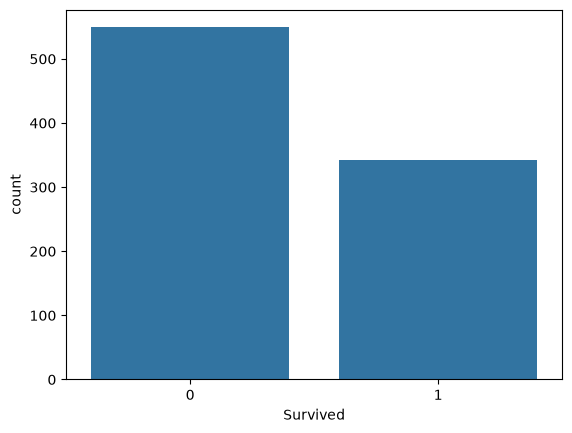

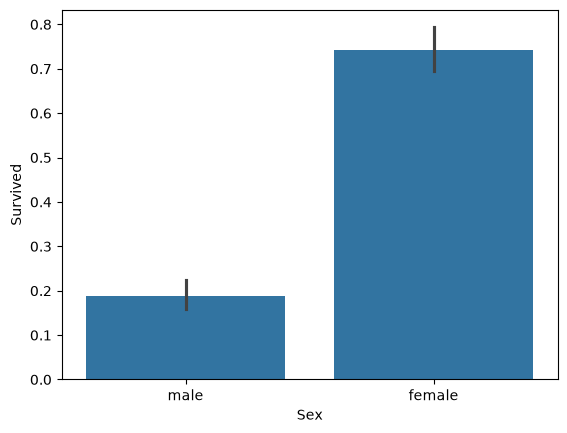

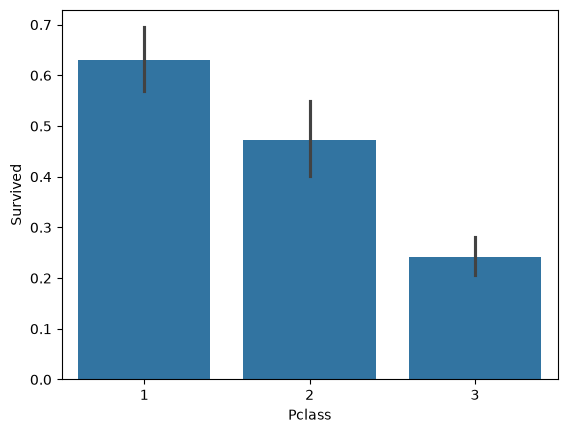

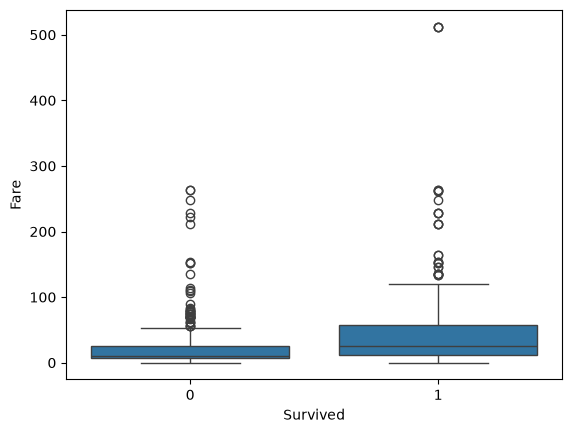

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_work, x="Survived")
plt.show()

sns.barplot(data=df_work, x="Sex", y="Survived")
plt.show()

sns.barplot(data=df_work, x="Pclass", y="Survived")
plt.show()

sns.boxplot(data=df_work, x="Survived", y="Fare")
plt.show()

그래프에서 보이는 차이는 관찰이고, 그 원인을 바로 단정하지 않습니다.

## STEP 09. 기초 통계와 EDA

In [11]:
sex_summary = (
    df_work.groupby("Sex", dropna=False)
    .agg(rows=("Survived", "size"), survival_rate=("Survived", "mean"))
)
display(sex_summary)

,rows,survival_rate
Sex,,
female,314,0.742038
male,577,0.188908


Fare 평균 차이 통계 검정

In [12]:
from scipy.stats import ttest_ind

survived_fare = df_work.loc[df_work["Survived"] == 1, "Fare"].dropna()
not_survived_fare = df_work.loc[df_work["Survived"] == 0, "Fare"].dropna()

stat, p_value = ttest_ind(
    survived_fare,
    not_survived_fare,
    equal_var=False,
)
print("t-statistic:", round(stat, 4))
print(f"p-value: {p_value:.3e}")

t-statistic: 6.8391
p-value: 2.699e-11


- H0: 생존자와 비생존자의 평균 Fare에는 차이가 없다.
- H1: 생존자와 비생존자의 평균 Fare에는 차이가 있다.

p-value < 0.05이면 보통 귀무가설을 기각합니다. `2.699e-11`처럼 표시되면 `e-11`은 `× 10⁻¹¹`이라는 뜻입니다.

## STEP 10. Feature 설계

- FamilySize = SibSp + Parch + 1
- IsAlone = FamilySize가 1이면 1, 아니면 0

이 두 Feature는 한 승객의 값만으로 계산할 수 있습니다.

In [13]:
feature_demo = df_work.copy()
feature_demo["FamilySize"] = (
    feature_demo["SibSp"] + feature_demo["Parch"] + 1
)
feature_demo["IsAlone"] = (
    feature_demo["FamilySize"] == 1
).astype(int)
display(feature_demo[["SibSp", "Parch", "FamilySize", "IsAlone"]].head())

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## Part 2. 머신러닝 모델링 (STEP 11–12)

Part 2부터는 원본 `df`에서 다시 시작합니다.

원본 df → FamilySize / IsAlone 직접 생성 → X / y → Train/Test split → 숫자형 결측치 처리
→ 범주형 결측치 처리 → One-Hot Encoding → 정규화와 표준화 비교 → StandardScaler 표준화
→ 숫자형 + 범주형 결합 → 모델 학습

## STEP 11. 학습/테스트 데이터 준비

### 11-1. 원본 df에서 모델링용 데이터 만들기

In [14]:
model_source = df.copy()
model_source["FamilySize"] = (
    model_source["SibSp"] + model_source["Parch"] + 1
)
model_source["IsAlone"] = (
    model_source["FamilySize"] == 1
).astype(int)

### 11-2. 사용할 Feature 직접 작성

In [15]:
raw_input_columns = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"
]
feature_columns = raw_input_columns + ["FamilySize", "IsAlone"]
numeric_features = [
    "Age", "SibSp", "Parch", "Fare", "FamilySize"
]
categorical_features = [
    "Pclass", "Sex", "Embarked", "IsAlone"
]

`Pclass`와 `IsAlone`은 숫자로 저장되어 있지만 의미상 범주로 취급합니다.

### 11-3. X와 y 만들기

In [16]:
X = model_source[feature_columns].copy()
y = model_source["Survived"].astype(int).copy()

### 11-4. Train/Test 분리

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

이 시점에는 `Sex`, `Embarked`가 문자열이고 `Age`, `Embarked`에 결측치가 남아 있어도 괜찮습니다.
먼저 분리하고 나중에 전처리합니다.

## STEP 12. 전처리를 하나씩 직접 실행하기

이번 STEP에서는 한꺼번에 묶지 않습니다.

1. 숫자형 결측치 처리
2. 범주형 결측치 처리
3. One-Hot Encoding
4. 정규화와 표준화 개념 비교
5. StandardScaler 표준화
6. 숫자형 + 범주형 데이터 결합
7. Logistic Regression 학습

### STEP 12-1. 숫자형 결측치 처리

In [18]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy="median")
X_train_num_imputed = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index,
)
X_test_num_imputed = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index,
)

핵심:

- Train → `fit_transform()`
- Test → `transform()`

즉 중앙값은 Train에서만 배웁니다.

### STEP 12-2. 범주형 결측치 처리

In [19]:
categorical_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat_imputed = pd.DataFrame(
    categorical_imputer.fit_transform(X_train[categorical_features]),
    columns=categorical_features,
    index=X_train.index,
)
X_test_cat_imputed = pd.DataFrame(
    categorical_imputer.transform(X_test[categorical_features]),
    columns=categorical_features,
    index=X_test.index,
)

최빈값도 Train에서만 배웁니다.

### STEP 12-3. One-Hot Encoding

In [20]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)
X_train_cat_encoded_array = encoder.fit_transform(X_train_cat_imputed)
X_test_cat_encoded_array = encoder.transform(X_test_cat_imputed)

encoded_feature_names = encoder.get_feature_names_out(categorical_features)
X_train_cat_encoded = pd.DataFrame(
    X_train_cat_encoded_array,
    columns=encoded_feature_names,
    index=X_train.index,
)
X_test_cat_encoded = pd.DataFrame(
    X_test_cat_encoded_array,
    columns=encoded_feature_names,
    index=X_test.index,
)

범주 목록 역시 Train에서 학습합니다.

### STEP 12-4. 정규화와 표준화 구분

두 용어를 구분합니다.

- **정규화 Normalization** (대표 예: MinMaxScaler) → 값을 보통 0~1 범위로 맞춤
- **표준화 Standardization** (대표 예: StandardScaler) → 평균 0, 표준편차 1을 기준으로 맞춤

먼저 정규화가 어떤 모습인지 개념 확인용으로 봅니다.

In [21]:
from sklearn.preprocessing import MinMaxScaler

minmax_demo = MinMaxScaler()
minmax_preview = pd.DataFrame(
    minmax_demo.fit_transform(
        X_train_num_imputed[["Age", "Fare"]]
    ),
    columns=["Age_minmax", "Fare_minmax"],
    index=X_train.index,
)
display(minmax_preview.head())

,Age_minmax,Fare_minmax
692,0.352852,0.110272
481,0.352852,0.000000
527,0.352852,0.432884
855,0.220910,0.018250
801,0.384267,0.051237


이 Min-Max 결과는 개념 확인용입니다. 이번 기본 Logistic Regression 모델에는 사용하지 않습니다.

### STEP 12-5. StandardScaler로 실제 표준화

이번 모델에서는 숫자형 Feature의 단위와 범위를 맞추기 위해 StandardScaler를 사용합니다.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num_imputed),
    columns=numeric_features,
    index=X_train.index,
)
X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num_imputed),
    columns=numeric_features,
    index=X_test.index,
)

다시 핵심은 같습니다.

- Train → `fit_transform()`
- Test → `transform()`

Test의 평균과 표준편차를 이용해 새 기준을 만들면 안 됩니다.

### STEP 12-6. 숫자형과 범주형 데이터 결합

In [23]:
X_train_ready = pd.concat(
    [X_train_num_scaled, X_train_cat_encoded],
    axis=1,
)
X_test_ready = pd.concat(
    [X_test_num_scaled, X_test_cat_encoded],
    axis=1,
)

print("X_train_ready:", X_train_ready.shape)
print("X_test_ready :", X_test_ready.shape)
print("missing train:", X_train_ready.isna().sum().sum())
print("missing test :", X_test_ready.isna().sum().sum())

X_train_ready: (712, 15)
X_test_ready : (179, 15)
missing train: 0
missing test : 0


이제 모델에 넣을 수 있는 숫자로만 이루어진 입력 데이터가 완성되었습니다.

### STEP 12-7. Logistic Regression Baseline 학습

In [24]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)
baseline_model.fit(X_train_ready, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

이 단계에서 학생이 직접 보는 흐름:

원본 문자열/결측 데이터 → 결측치 처리 → 범주형 인코딩 → 숫자형 표준화 → 최종 숫자 데이터 → 모델 학습

STEP 13부터는 이 `baseline_model`을 평가하고, 추가 모델과 비교한 뒤 저장과 서비스로 이어집니다.